<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-3/3_3_Data_visualization_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Visualization - Iris

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as dss

### Load the Data

In [2]:
# Читаємо ваш локальний файл Iris.csv
df = pd.read_csv('Iris.csv')

# Якщо у файлі є зайва колонка 'Id', ми її видаляємо, щоб вона не псувала графіки
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Автоматично створюємо список ознак (всі колонки, крім Species)
feature_names = [col for col in df.columns if col != 'Species']

print(f"Успішно! Завантажено {df.shape[0]} рядків датасету Iris.")
print(f"Ознаки для графіків: {feature_names}")

Успішно! Завантажено 150 рядків датасету Iris.
Ознаки для графіків: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


### Pairwise correlation of columns

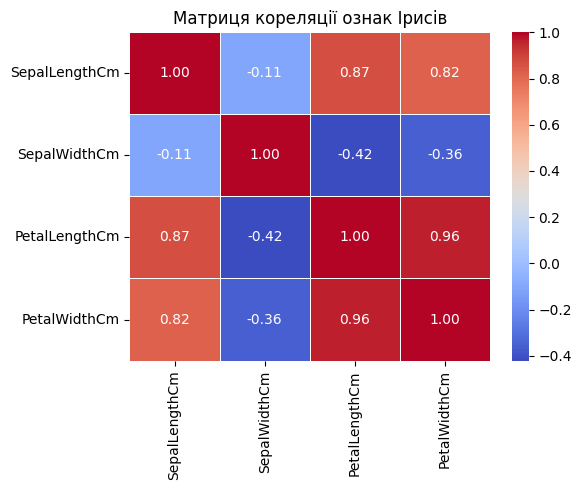

In [5]:
# 1. Рахуємо кореляцію ТІЛЬКИ для числових колонок (feature_names)
# Ми передаємо таблицю df[feature_names], де немає тексту
corr = df[feature_names].corr()

# 2. Будуємо теплокарту
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляції ознак Ірисів', fontsize=12)
plt.tight_layout()
plt.show()

### Boxplots
for more examples see https://seaborn.pydata.org/generated/seaborn.boxplot.html

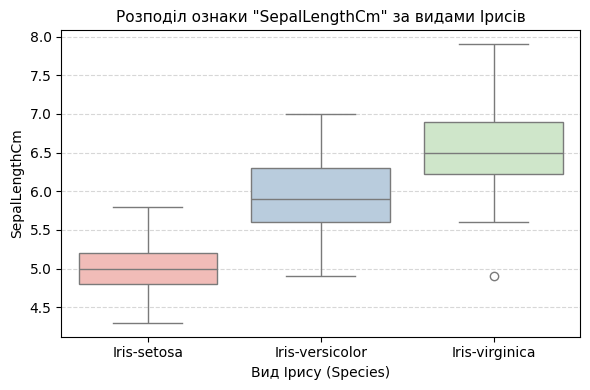

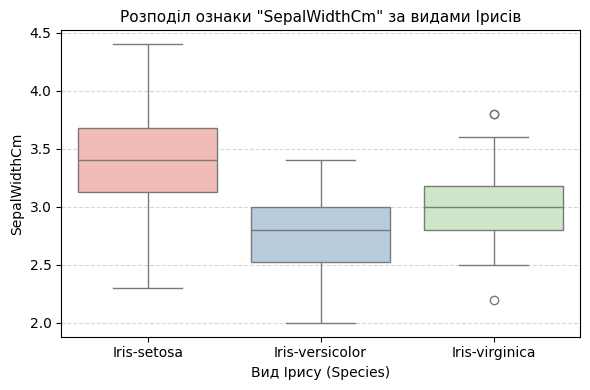

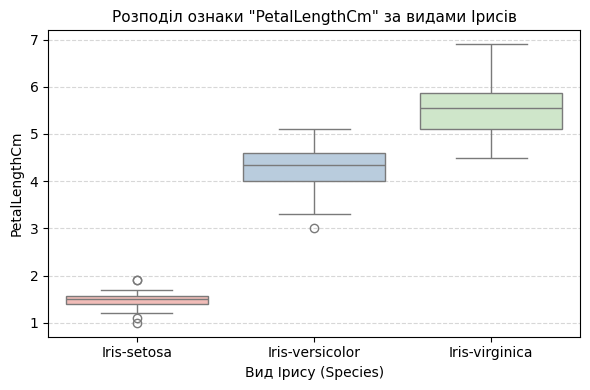

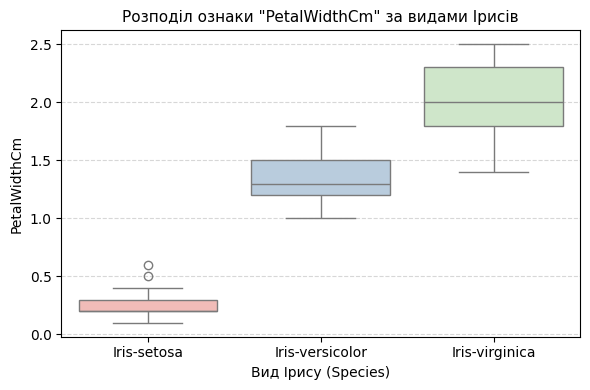

In [8]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Цикл малює боксплот для кожної числової ознаки
for i in range(len(feature_names)):
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x='Species',        # Групуємо на осі X за назвами квітів
        y=feature_names[i], # Числова ознака на осі Y
        data=df,
        hue='Species',      # Обов'язково додаємо для нових версій Seaborn
        palette='Pastel1',  # Гарні ніжні кольори
        legend=False        # Вимикаємо дублювання легенди
    )
    plt.title(f'Розподіл ознаки "{feature_names[i]}" за видами Ірисів', fontsize=11)
    plt.xlabel('Вид Ірису (Species)')
    plt.ylabel(feature_names[i])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Pairplot
for more examples see
https://seaborn.pydata.org/generated/seaborn.pairplot.html

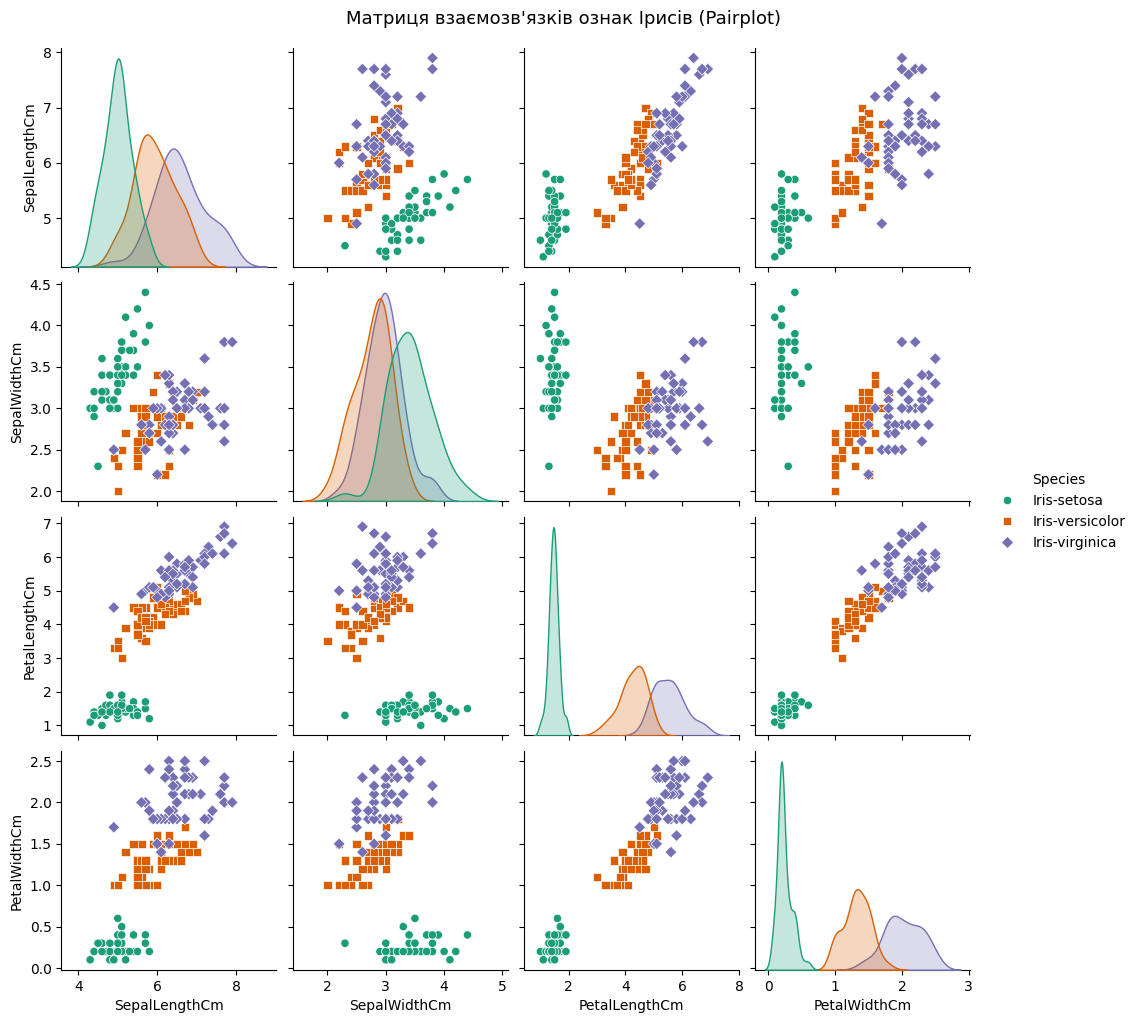

In [9]:
# Будуємо матрицю взаємозв'язків (усі ознаки з усіма)
sns.pairplot(
    df,
    hue='Species',       # Групуємо та фарбуємо точки за видом квітки
    palette='Dark2',     # Контрастна та гарна палітра кольорів
    markers=["o", "s", "D"] # Різні фігурки для кожного виду (коло, квадрат, ромб)
)
plt.suptitle('Матриця взаємозв\'язків ознак Ірисів (Pairplot)', y=1.02, fontsize=13)
plt.show()